In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
data = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.shape

(7043, 21)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Data Dictionary

| # | Feature | Description |
|---|---|---|
| 1 | `CustomerID` | Unique identifier for each customer. |
| 2 | `Gender` | Customer's gender: Male or Female. |
| 3 | `Age` | Customer's age, in years, at the end of the fiscal quarter. |
| 4 | `Senior Citizen` | Indicates whether the customer is 65 years old or older: Yes or No. |
| 5 | `Married (Partner)` | Indicates whether the customer is married: Yes or No. |
| 6 | `Dependents` | Indicates whether the customer lives with dependents: Yes or No. Dependents may include children, parents, grandparents, etc. |
| 7 | `Number of Dependents` | Number of dependents living with the customer. |
| 8 | `Phone Service` | Indicates whether the customer subscribes to home phone service: Yes or No. |
| 9 | `Multiple Lines` | Indicates whether the customer subscribes to multiple telephone lines: Yes or No. |
| 10 | `Internet Service` | Type of Internet service: No, DSL, Fiber Optic, or Cable. |
| 11 | `Online Security` | Indicates whether the customer subscribes to an additional online security service: Yes or No. |
| 12 | `Online Backup` | Indicates whether the customer subscribes to an additional online backup service: Yes or No. |
| 13 | `Device Protection Plan` | Indicates whether the customer subscribes to a device protection plan: Yes or No. |
| 14 | `Premium Tech Support` | Indicates whether the customer subscribes to additional technical support with reduced wait times: Yes or No. |
| 15 | `Streaming TV` | Indicates whether the customer uses the Internet service to stream television content: Yes or No. |
| 16 | `Streaming Movies` | Indicates whether the customer uses the Internet service to stream movies: Yes or No. |
| 17 | `Contract` | Customer's current contract type: Month-to-Month, One Year, or Two Year. |
| 18 | `Paperless Billing` | Indicates whether the customer uses paperless billing: Yes or No. |
| 19 | `Payment Method` | Customer's payment method: Bank Withdrawal, Credit Card, or Mailed Check. |
| 20 | `Monthly Charge` | Customer's current monthly charge for all contracted services. |
| 21 | `Total Charges` | Total amount charged to the customer up to the end of the quarter. |
| 22 | `Tenure` | Total number of months the customer has been with the company. |
| 23 | `Churn` | Indicates whether the customer left the company during the quarter: Yes or No. |

In [6]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [16]:
data['TotalCharges'].isnull().sum()
linhas_data_nulos = data.loc[data['TotalCharges'].isnull()]
linhas_data_nulos

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [17]:
data['TotalCharges'] = data['TotalCharges'].fillna(0)

Os 11 valores ausentes em TotalCharges pertencem a clientes com tenure = 0. Como ainda não houve tempo de permanência para acumular cobranças, os valores foram substituídos por zero.

In [20]:
data['customerID'].nunique() == len(data)

True

In [22]:
data.duplicated().sum()

np.int64(0)

In [11]:
# data.describe(include='str')
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


### Variavel Alvo

In [20]:
data['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [21]:
data['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

findfont: Failed to find font weight normal, now using 500.


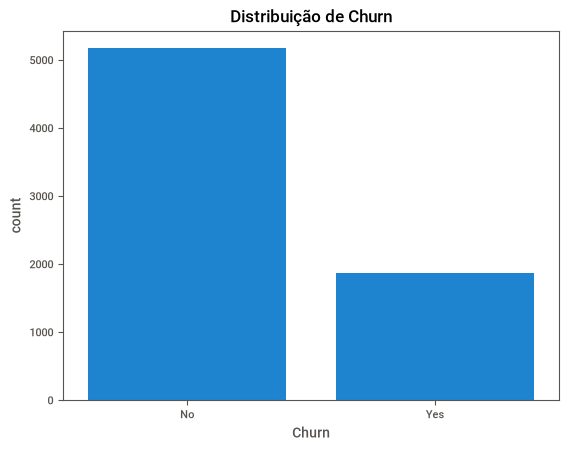

In [22]:
sns.countplot(data=data, x='Churn')
plt.title('Distribuição de Churn')
plt.show()

A taxa de churn é de 26,54%, indicando um desbalanceamento moderado da variável-alvo.

Separando em variaveis numericas e catégoricas

In [55]:
numeric_cols = data.select_dtypes('number')
categorical_cols = data.select_dtypes('string')


In [68]:
categorical_cols = categorical_cols.drop('customerID', axis=1)

### Analisando as variaveis numericas

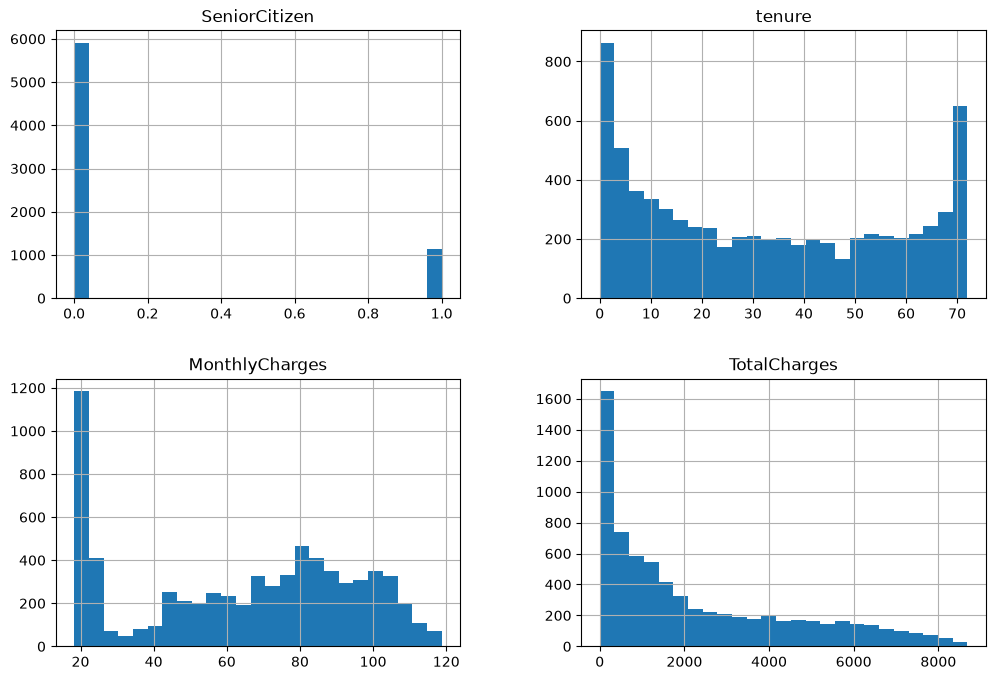

In [60]:
numeric_cols.hist(bins=25, figsize=(12,8))
plt.show()

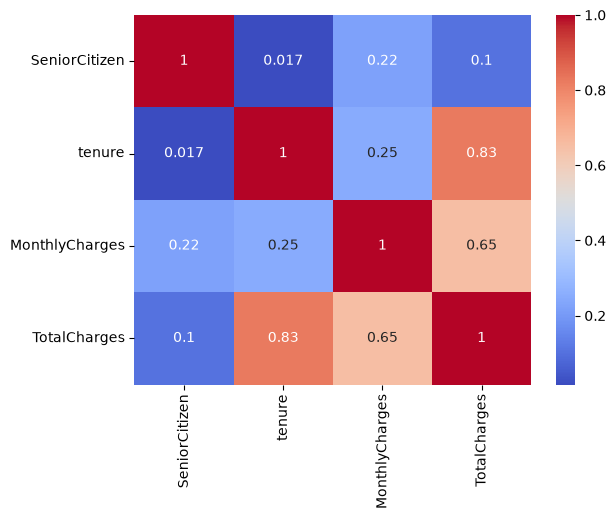

In [59]:
corr = numeric_cols.corr()
sns.heatmap(data=corr,cmap='coolwarm', annot=True)
plt.show()

### Analisando as variaveis catégoricas

In [69]:
for col in categorical_cols.columns:
    print(f"\n--- {col} ---")
    print(data[col].value_counts())
    print(data[col].value_counts(normalize=True) * 100)


--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64
gender
Male      50.47565
Female    49.52435
Name: proportion, dtype: float64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Partner
No     51.69672
Yes    48.30328
Name: proportion, dtype: float64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
Dependents
No     70.041176
Yes    29.958824
Name: proportion, dtype: float64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
PhoneService
Yes    90.316626
No      9.683374
Name: proportion, dtype: float64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
MultipleLines
No                  48.132898
Yes                 42.183729
No phone service     9.683374
Name: proportion, dtype: float64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             

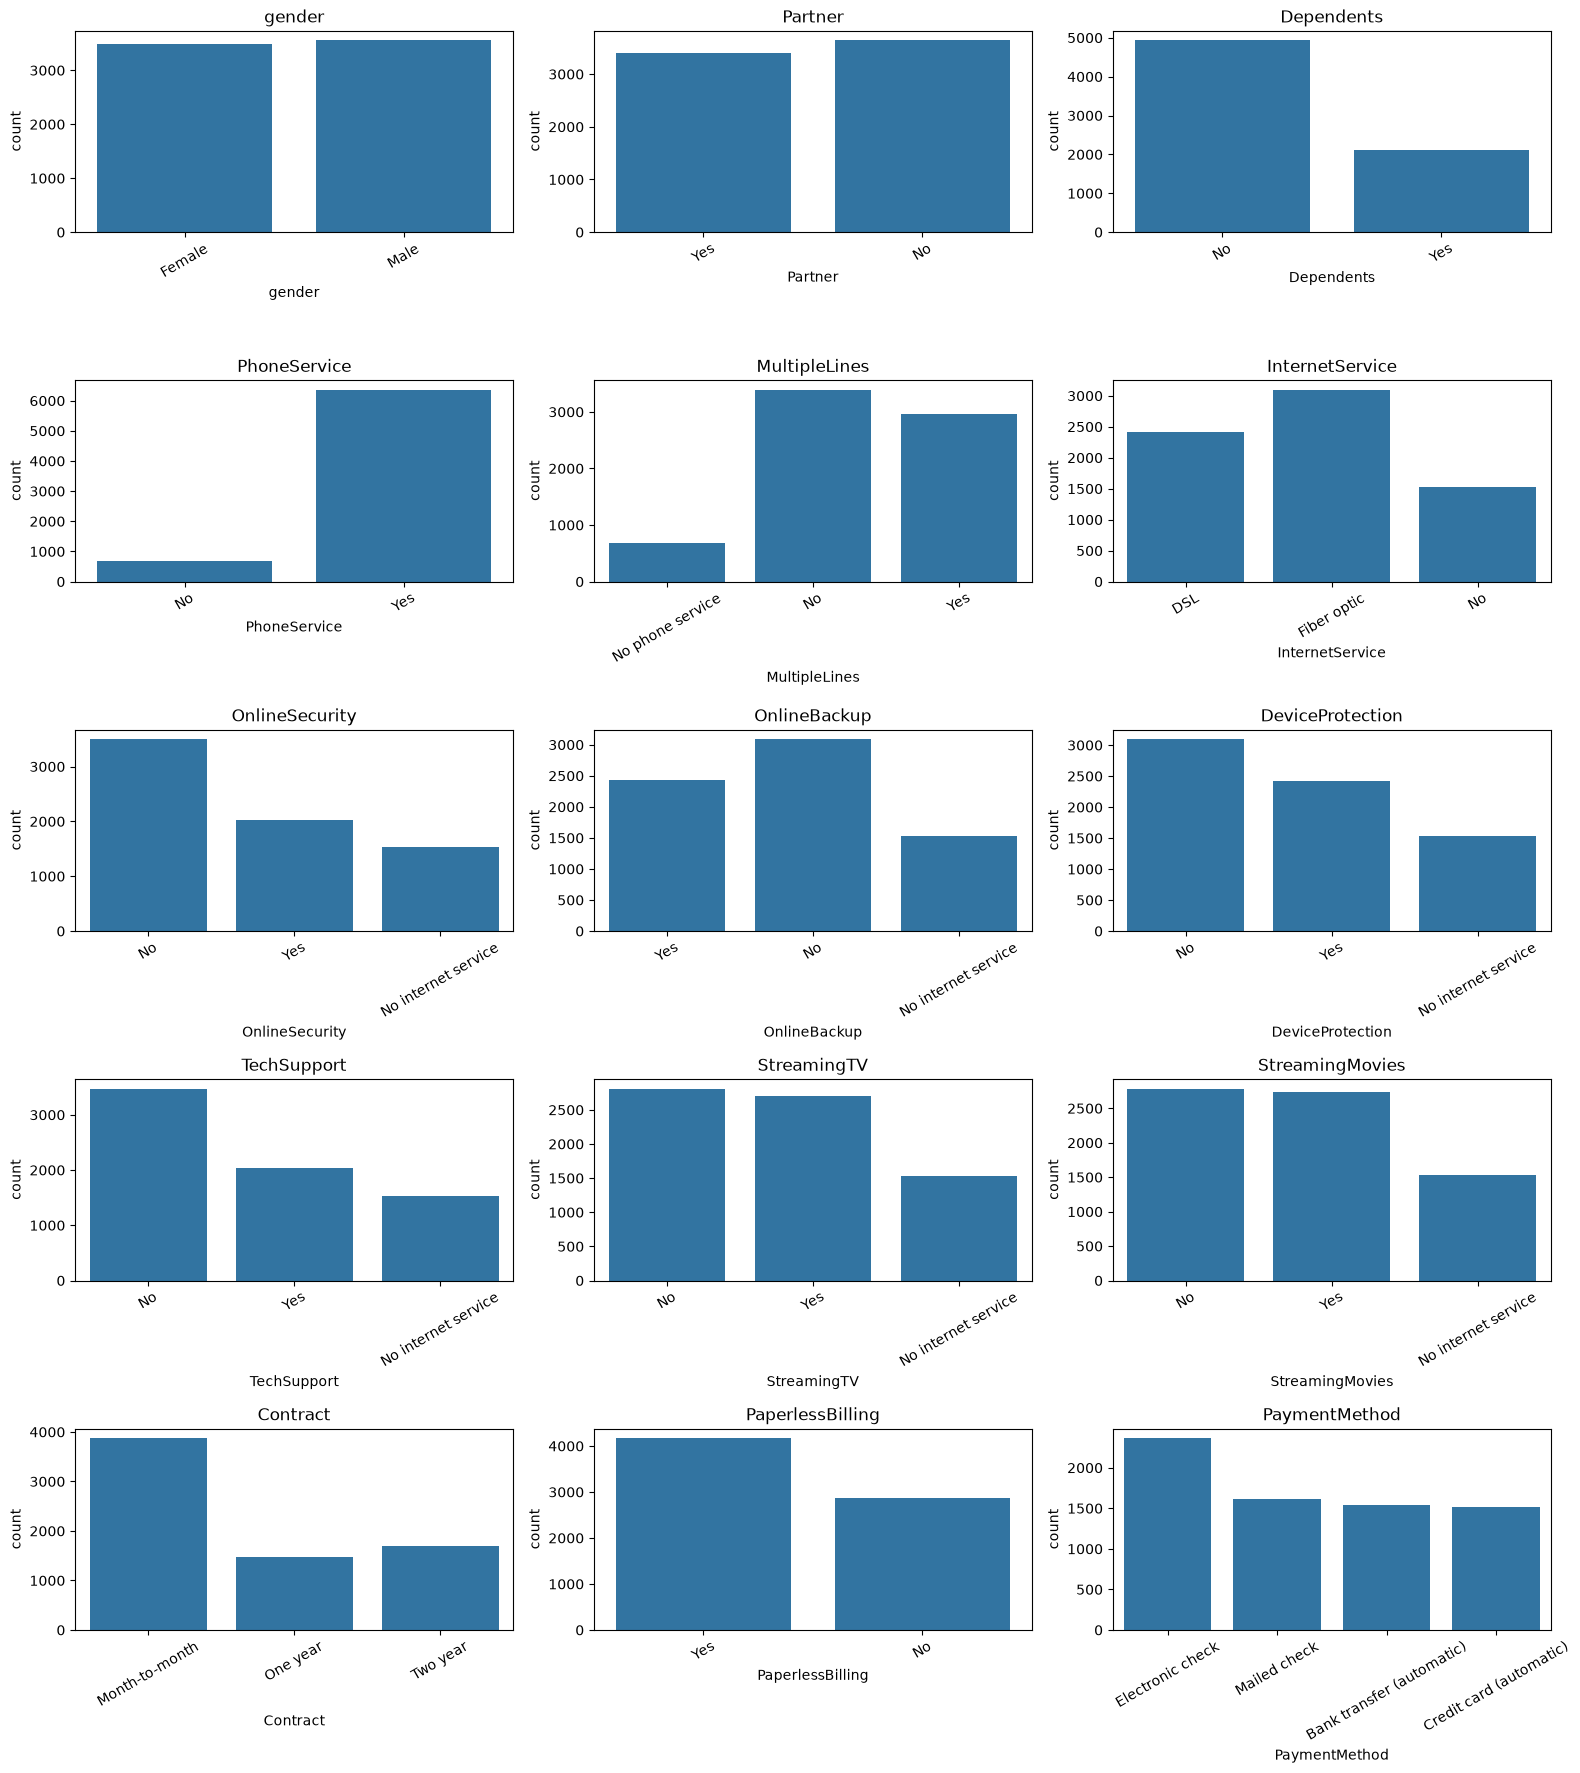

In [73]:
colunas = categorical_cols.drop(columns="Churn").columns

plt.figure(figsize=(16, 20))

for i, coluna in enumerate(colunas):
    plt.subplot(6, 3, i + 1)
    sns.countplot(data=data, x=coluna)
    plt.title(coluna)
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Analisar relação com a variável alvo

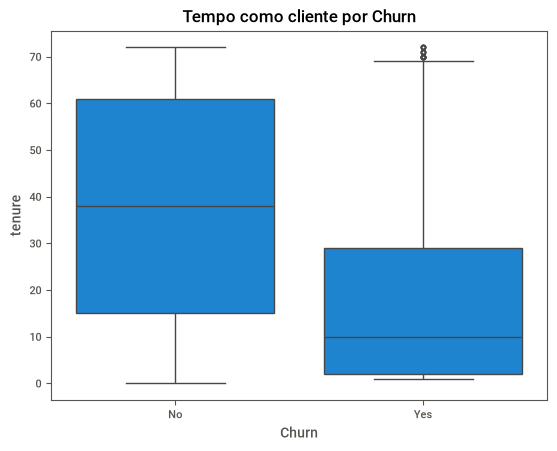

In [23]:
sns.boxplot(data=data, x='Churn', y='tenure')
plt.title('Tempo como cliente por Churn')
plt.show()

In [24]:
data.groupby('Churn')['tenure'].median()

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64

Clientes que cancelaram possuem mediana de 10 meses de permanência, enquanto os que não cancelaram possuem mediana de 38 meses. Isso sugere maior churn entre clientes mais recentes.

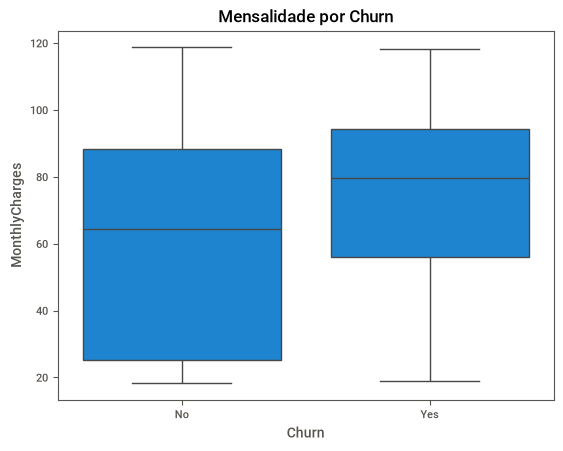

In [25]:
sns.boxplot(data=data, x='Churn', y='MonthlyCharges')
plt.title('Mensalidade por Churn')
plt.show()

In [26]:
data.groupby('Churn')['MonthlyCharges'].median()

Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64

Clientes que cancelaram apresentam mensalidade mediana maior. Isso indica uma associação entre mensalidades mais altas e churn, mas não comprova causalidade.

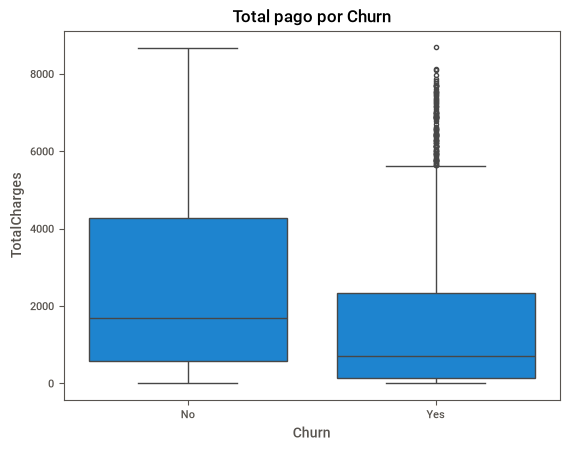

In [27]:
sns.boxplot(data=data, x='Churn', y='TotalCharges')
plt.title('Total pago por Churn')
plt.show()

In [28]:
data.groupby('Churn')['TotalCharges'].median()

Churn
No     1679.525
Yes     703.550
Name: TotalCharges, dtype: float64

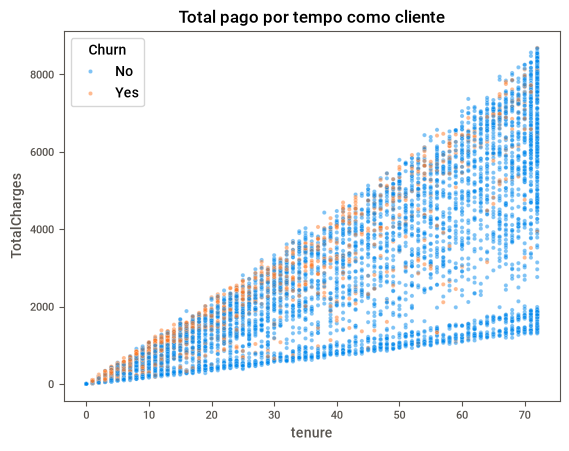

In [29]:
sns.scatterplot(
    data=data,
    x='tenure',
    y='TotalCharges',
    hue='Churn',
    alpha=0.5
)
plt.title('Total pago por tempo como cliente')
plt.show()

O TotalCharges cresce com o tenure. Para tempos semelhantes, valores acumulados maiores parecem estar associados ao churn, possivelmente devido a mensalidades mais altas.

In [30]:
pd.crosstab(data['Contract'], data['Churn'], normalize='index')*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


Clientes com contrato mensal apresentam churn de 42,71%, muito superior aos contratos de um ano (11,27%) e dois anos (2,83%).

In [31]:
pd.crosstab(data['PaymentMethod'], data['Churn'], normalize='index')*100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


Electronic check apresenta a maior taxa de churn, com 45,29%. Essa associação pode também estar relacionada a outros fatores, como o tipo de contrato.

In [32]:
pd.crosstab(data['InternetService'], data['Churn'], normalize='index')*100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


Clientes com fibra óptica apresentam a maior taxa de churn (41,89%). É necessário investigar se isso está relacionado ao preço ou aos serviços adicionais.

In [33]:
pd.crosstab(data['OnlineSecurity'], data['Churn'], normalize='index') * 100

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


In [34]:
pd.crosstab(data['TechSupport'], data['Churn'], normalize='index')*100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


A ausência de segurança online e suporte técnico está associada a taxas maiores de churn. Essa relação não comprova que a ausência desses serviços seja a causa do cancelamento.

In [35]:
pd.crosstab(data['Partner'], data['Churn'], normalize='index')*100

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


In [36]:
pd.crosstab(data['Dependents'], data['Churn'], normalize='index')*100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


Clientes sem parceiro e sem dependentes apresentam taxas maiores de churn, sugerindo maior retenção entre clientes com vínculos familiares.

In [37]:
pd.crosstab(data['SeniorCitizen'], data['Churn'], normalize='index')*100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


In [38]:
pd.crosstab(data['gender'], data['Churn'], normalize='index')*100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


Clientes idosos apresentam maior taxa de churn (41,7%). O gênero não demonstrou associação relevante, pois os percentuais foram semelhantes.

In [39]:
pd.crosstab(data['PaperlessBilling'],data['Churn'],normalize='index') * 100

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


Clientes com cobrança sem papel apresentam churn de 33,57%, contra 16,33% entre aqueles sem cobrança digital.

In [40]:
pd.crosstab(data['PhoneService'], data['Churn'], normalize='index') * 100

Churn,No,Yes
PhoneService,,
No,75.073314,24.926686
Yes,73.290363,26.709637


In [41]:
pd.crosstab(data['MultipleLines'], data['Churn'], normalize='index') * 100

Churn,No,Yes
MultipleLines,,
No,74.955752,25.044248
No phone service,75.073314,24.926686
Yes,71.390104,28.609896


PhoneService e MultipleLines apresentam diferenças pequenas nas taxas de churn, sugerindo baixa associação individual.

In [42]:
pd.crosstab(data['OnlineBackup'], data['Churn'], normalize='index') * 100

Churn,No,Yes
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


In [43]:
pd.crosstab(data['DeviceProtection'], data['Churn'], normalize='index') * 100

Churn,No,Yes
DeviceProtection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


Clientes sem backup online e sem proteção do dispositivo apresentam taxas maiores de churn.

In [44]:
pd.crosstab(data['StreamingTV'], data['Churn'], normalize='index') * 100

Churn,No,Yes
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


In [45]:
pd.crosstab(data['StreamingMovies'], data['Churn'], normalize='index') * 100

Churn,No,Yes
StreamingMovies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


In [46]:
pd.crosstab(
    index=[data['Contract'], data['InternetService']],
    columns=data['Churn'],
    normalize='index'
)['Yes'].sort_values(ascending=False) * 100

Contract        InternetService
Month-to-month  Fiber optic        54.605263
                DSL                32.215863
One year        Fiber optic        19.294991
Month-to-month  No                 18.893130
One year        DSL                 9.298246
Two year        Fiber optic         7.226107
One year        No                  2.472527
Two year        DSL                 1.910828
                No                  0.783699
Name: Yes, dtype: float64

Clientes com contrato mensal e fibra óptica formam o grupo de maior risco, com churn de 54,61%.

In [47]:
pd.crosstab(
    index=[data['Contract'], data['PaymentMethod']],
    columns=data['Churn'],
    normalize='index'
)['Yes'].sort_values(ascending=False) * 100

Contract        PaymentMethod            
Month-to-month  Electronic check             53.729730
                Bank transfer (automatic)    34.125637
                Credit card (automatic)      32.780847
                Mailed check                 31.578947
One year        Electronic check             18.443804
                Credit card (automatic)      10.301508
                Bank transfer (automatic)     9.718670
Two year        Electronic check              7.738095
One year        Mailed check                  6.824926
Two year        Bank transfer (automatic)     3.368794
                Credit card (automatic)       2.237522
                Mailed check                  0.785340
Name: Yes, dtype: float64

In [48]:
resumo = (
    data.groupby(['Contract', 'PaymentMethod'])['Churn']
    .agg(
        clientes='size',
        cancelamentos=lambda x: (x == 'Yes').sum(),
        taxa_churn=lambda x: (x == 'Yes').mean() * 100
    )
    .sort_values('taxa_churn', ascending=False)
)

resumo

clientes  cancelamentos  taxa_churn
Contract       PaymentMethod                                                 
Month-to-month Electronic check               1850            994   53.729730
               Bank transfer (automatic)       589            201   34.125637
               Credit card (automatic)         543            178   32.780847
               Mailed check                    893            282   31.578947
One year       Electronic check                347             64   18.443804
               Credit card (automatic)         398             41   10.301508
               Bank transfer (automatic)       391             38    9.718670
Two year       Electronic check                168             13    7.738095
One year       Mailed check                    337             23    6.824926
Two year       Bank transfer (automatic)       564             19    3.368794
               Credit card (automatic)         581             13    2.237522
               Mailed check                    382              3    0.785340

## Principais conclusões
1. Verificando os dados de churn, podemos concluir que existe um desbalanceamento entre as classes, com a classe churn com apenas 26,54% de ocorrencia;

2. verificando a relação de tenure e monthlycharges podemos perceber que existe uma associação ao alto indice de churn quando temos um alto valor de mensalidade e um baixo tempo de permanencia. Na variavel tenure existe uma mediana de 10,0 para churn e 38,0 para ausencia de churn. Ja em monthlycharges, temos uma mediana de 79,6 para churn e 64,4 para ausencia de churn;

3. Em relação ao contrato, internet e pagamento, podemos visualizar um alto indice de churn quando temos de forma respectiva o seguinte modelo: month-month, fiberoptic, e eletroniccheck;

4. Sobre segurança, suporte, backup e proteção, temos um alto churn para as seguintes afirmações: ausencia de segurança, ausencia de suporte, ausencia de backup, ausencia de proteção;

5. as variaveis com menor relação são: Phoneservice, multiple Lines, streamingmovies, streamingtv, gender;

6. Os fatores individualmente associados ao churn são: contrato mensal, eletronicchek, fiberoptic, ausencia de seguranca, ausencia de suporte, ausencia de parceiro, ausencia de dependentes, idoso, cobrança sem papel, ausencia de backup, ausencia de protecao. Alem disso combinando as variaveis, existe churn para um perfil que possui contratol mensal e utiliza fibra otica, com 54,6% de churn, outra combinação relevante seria um perfil que possui contrato mensal e utiliza cheque eletronico, com 53,7% de churn.

In [49]:
taxa_de_contrato = pd.crosstab(data['Contract'], data['Churn'], normalize='index')*100

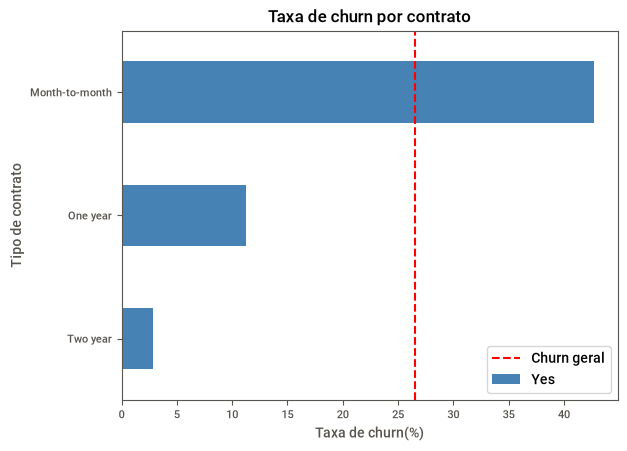

In [72]:

taxa_de_contrato['Yes'].sort_values().plot(kind='barh', color='steelblue')

plt.axvline(26.54, color = 'red', linestyle = '--', label = 'Churn geral')

plt.xlabel('Taxa de churn(%)')
plt.ylabel('Tipo de contrato')
plt.title('Taxa de churn por contrato')
plt.legend()
plt.show()

Clientes com contrato mensal apresentam churn de 42,71%, ficando 16,17 pontos percentuais acima da taxa geral de 26,54%. Contratos de um e dois anos ficam abaixo da média.

In [73]:
taxa_internet = pd.crosstab(data['InternetService'], data['Churn'], normalize='index')* 100


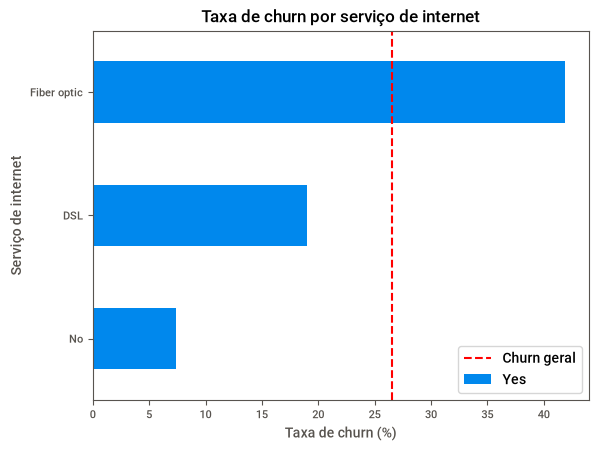

In [74]:
taxa_internet['Yes'].sort_values().plot(kind='barh')

plt.axvline(26.54, color='red', linestyle='--', label='Churn geral')
plt.xlabel('Taxa de churn (%)')
plt.ylabel('Serviço de internet')
plt.title('Taxa de churn por serviço de internet')
plt.legend()
plt.show()

Clientes com fibra óptica apresentam churn de 41,89%, ficando 15,35 pontos percentuais acima da taxa geral.